----
# **<span style="color:DARKGREEN">PROYECTO MACHINE LEARNING ESTUDIANTES</span>**
# **<span style="color:DARKGREEN">Análisis exploratorio</span>**
----

---
---

---
---
## <span style="color:gray">**1. Importación de librerías**</span> 📂

In [3]:
# Importación de librerías
# -----------------------------------------------------------------------
# Tratamiento de los datos
import numpy as np
import pandas as pd
# Visualizaciones de los datos
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de Pandas
# -----------------------------------------------------------------------
pd.set_option('display.max_columns', None)  # Para visualizar todas las columnas de los DataFrames

---
---
## <span style="color:gray">**2. Carga de datos**</span> 📥

In [8]:
df = pd.read_csv("../data/raw/dataset_estudiantes.csv")

In [9]:
df.head()

,horas_estudio_semanal,nota_anterior,tasa_asistencia,horas_sueno,edad,nivel_dificultad,tiene_tutor,horario_estudio_preferido,estilo_aprendizaje,nota_final,aprobado
0,8.957476,48.830601,86.640182,6.675694,25,Fácil,Sí,Tarde,Lectura/Escritura,84.4,1
1,11.042524,80.825707,83.449655,4.616844,18,Difícil,No,Tarde,NaN,72.0,1
2,4.510776,90.383694,74.623607,7.755246,25,Fácil,No,Mañana,Lectura/Escritura,80.0,1
3,6.647213,81.878257,82.849841,8.592826,23,Fácil,No,NaN,Visual,78.2,1
4,1.000000,66.254179,54.539935,6.671840,21,Medio,No,NaN,Auditivo,66.0,1


---
---
## <span style="color:gray">**Análisis exploratorio**</span> 🔎

---

### 📏 Dimensión del DataFrame

In [12]:
print(f'Número de filas del DataFrame: {df.shape[0]}')
print(f'Número de columnas del DataFrame: {df.shape[1]}')

Número de filas del DataFrame: 1000
Número de columnas del DataFrame: 11


---

### 🏷️ Nombres de las columnas

In [11]:
df.columns

Index(['horas_estudio_semanal', 'nota_anterior', 'tasa_asistencia',
       'horas_sueno', 'edad', 'nivel_dificultad', 'tiene_tutor',
       'horario_estudio_preferido', 'estilo_aprendizaje', 'nota_final',
       'aprobado'],
      dtype='str')

Descripción de las columnas

- **`horas_estudio_semanal`**: Número de horas de estudio a la semana.

- **`nota_anterior`**: Nota que obtuvo el alumno en la convocatoria anterior.

- **`tasa_asistencia`**: Tasa de asistencia a clase en porcentaje.

- **`horas_sueno`**: Promedio de horas que duerme el alumno al día.

- **`edad`**: Edad del alumno.

- **`nivel_dificultad`**: Dificultad del alumno para el estudio.

- **`tiene_tutor`**: Indica si el alumno tiene tutor o no.

- **`horario_estudio_preferido`**: Horario de estudio preferido por el alumno.

- **`estilo_aprendizaje`**: Forma de estudio que emplea el alumno.

- **`nota_final`**: Nota final obtenida por el alumno, expresada en una escala de 0 a 100.

- **`aprobado`**: Indica si el alumno ha aprobado o no. Toma el valor 1 si la nota final es ≥ 60 y 0 si la nota final es < 60. 

---

### 🧾 Información general

In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   horas_estudio_semanal      1000 non-null   float64
 1   nota_anterior              1000 non-null   float64
 2   tasa_asistencia            1000 non-null   float64
 3   horas_sueno                850 non-null    float64
 4   edad                       1000 non-null   int64  
 5   nivel_dificultad           1000 non-null   str    
 6   tiene_tutor                1000 non-null   str    
 7   horario_estudio_preferido  900 non-null    str    
 8   estilo_aprendizaje         950 non-null    str    
 9   nota_final                 1000 non-null   float64
 10  aprobado                   1000 non-null   int64  
dtypes: float64(5), int64(2), str(4)
memory usage: 86.1 KB


---

### 🔁 Identificación de duplicados

In [16]:
print(f'El número de duplicados del dataset es: {df.duplicated().sum()}')

El número de duplicados del dataset es: 0


---

### ❌ Detección de nulos

In [17]:
nulos = df.isnull().sum()
if nulos.any() > 0:
        print(f"El número de valores nulos de cada columna es: \n\n{nulos[nulos > 0]}\n")    
else:
        print('No hay nulos')

nulos_porcentaje = df.isnull().sum() / (df.shape[0])*100
if nulos_porcentaje.any() > 0:
        print(f"El porcentaje de valores nulos de cada columna es: \n\n{nulos_porcentaje[nulos_porcentaje > 0].round(4)}")
else:
       pass

El número de valores nulos de cada columna es: 

horas_sueno                  150
horario_estudio_preferido    100
estilo_aprendizaje            50
dtype: int64

El porcentaje de valores nulos de cada columna es: 

horas_sueno                  15.0
horario_estudio_preferido    10.0
estilo_aprendizaje            5.0
dtype: float64


---

### 🔣 Identificar variables numéricas y variables categóricas

In [19]:
num_cols = df.select_dtypes(include=np.number).columns
cat_cols = df.select_dtypes(include=['str', 'category']).columns

print("Variables numéricas:\n\n", num_cols)
print("\nVariables categóricas:\n\n", cat_cols)

Variables numéricas:

 Index(['horas_estudio_semanal', 'nota_anterior', 'tasa_asistencia',
       'horas_sueno', 'edad', 'nota_final', 'aprobado'],
      dtype='str')

Variables categóricas:

 Index(['nivel_dificultad', 'tiene_tutor', 'horario_estudio_preferido',
       'estilo_aprendizaje'],
      dtype='str')


---

### 🔢 Variables numéricas

#### Estadísticas descriptivas

In [20]:
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
horas_estudio_semanal,1000.0,10.07,4.85,1.0,6.63,10.00,13.37,25.0
nota_anterior,1000.0,69.89,14.69,30.0,59.88,70.00,80.12,100.0
tasa_asistencia,1000.0,73.99,18.20,20.0,61.51,75.00,88.49,100.0
horas_sueno,850.0,7.01,1.44,4.0,6.00,7.02,8.02,10.0
edad,1000.0,23.53,3.48,18.0,21.00,24.00,27.00,29.0
nota_final,1000.0,71.44,9.56,30.0,64.78,71.40,77.90,100.0
aprobado,1000.0,0.90,0.30,0.0,1.00,1.00,1.00,1.0


##### Visualizaciones

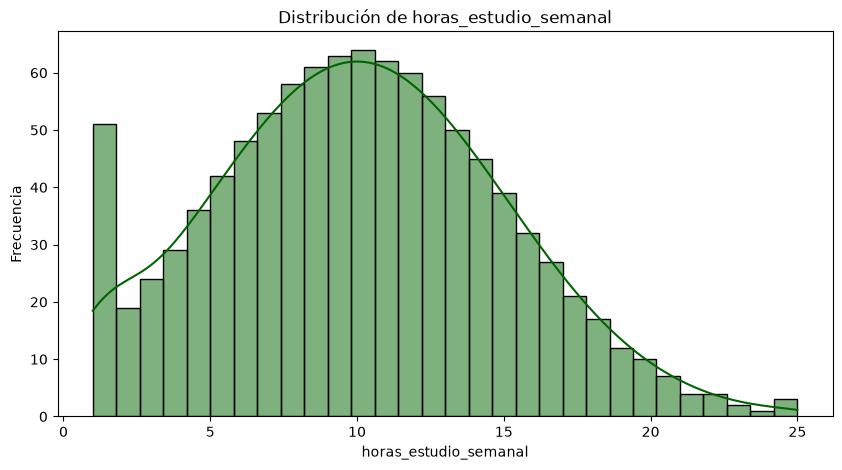

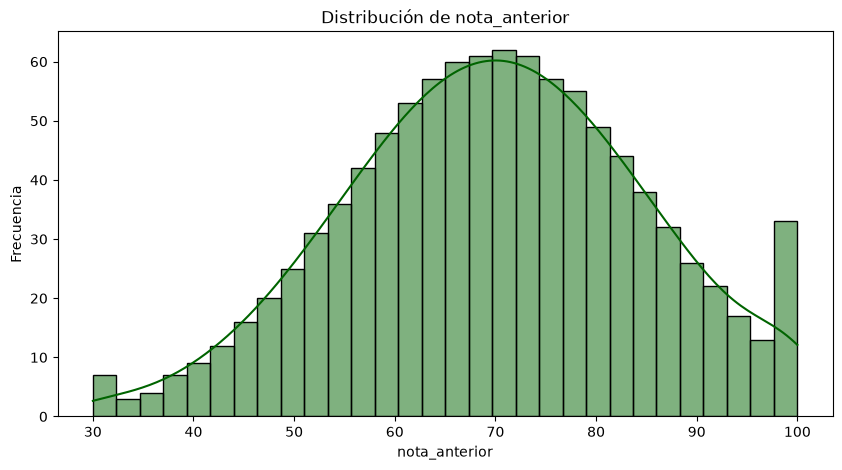

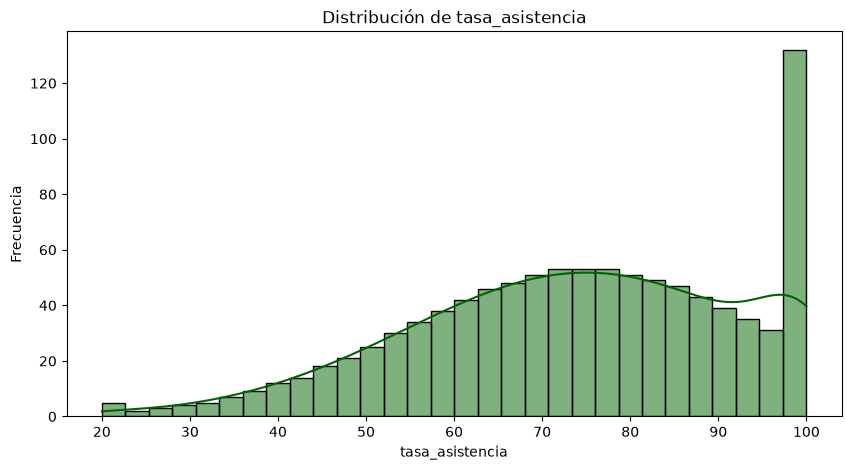

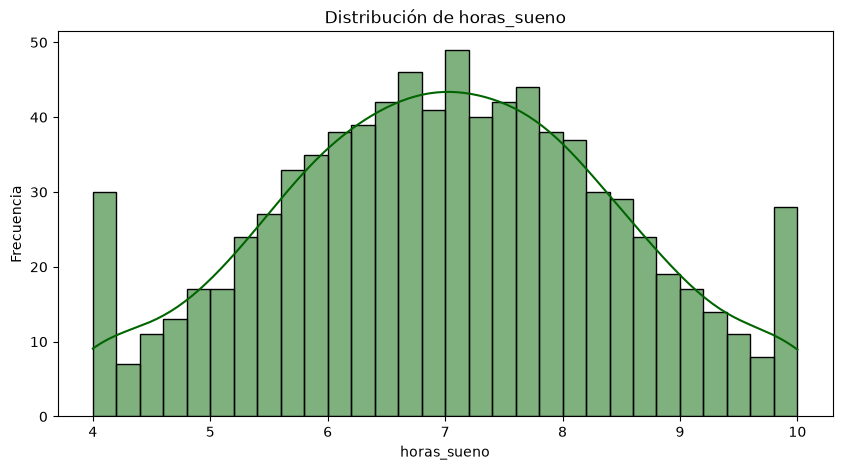

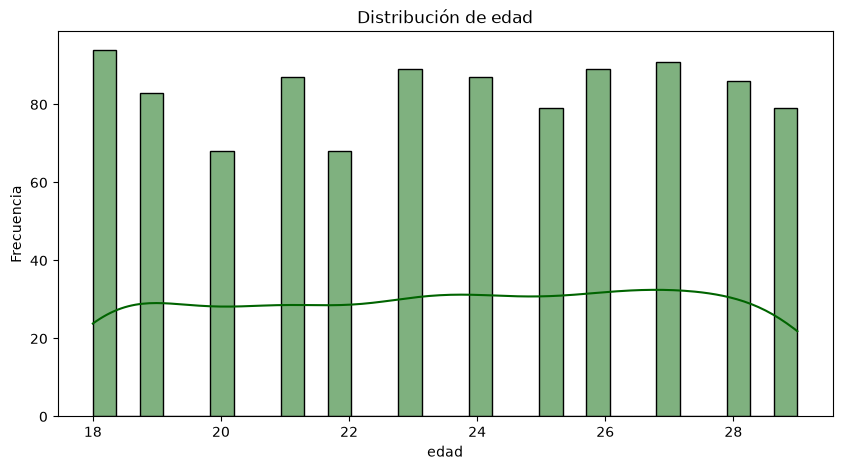

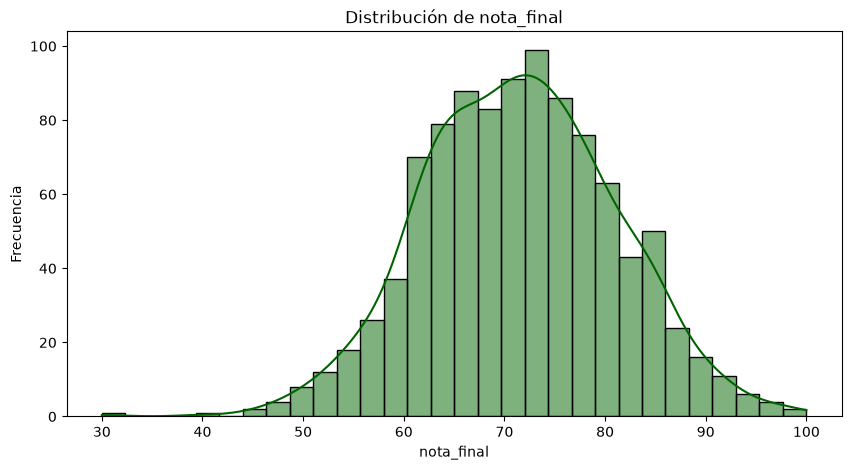

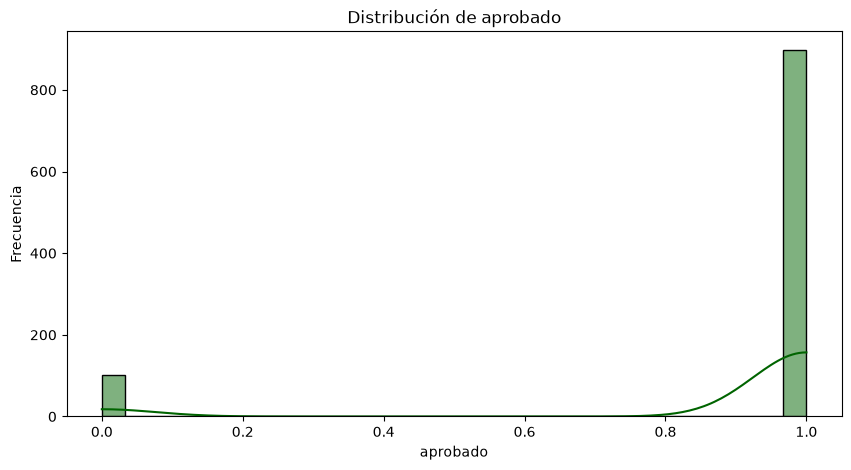

In [33]:
for col in num_cols:
    
    plt.figure(figsize=(10, 5))
    sns.histplot(df[col], bins=30, kde=True, color='darkgreen', edgecolor='black')

    plt.title(f'Distribución de {col}')
    plt.xlabel(col)
    plt.ylabel('Frecuencia')

    plt.show()

---

### 🔡 Variables categóricas

#### Estadísticas descriptivas

In [30]:
df.describe(include = "str").T

,count,unique,top,freq
nivel_dificultad,1000,3,Medio,504
tiene_tutor,1000,2,No,597
horario_estudio_preferido,900,3,Noche,344
estilo_aprendizaje,950,4,Visual,363


#### Valores únicos y frecuencias

In [31]:
for col in cat_cols:
    print(f" \n----------- ESTAMOS ANALIZANDO LA COLUMNA: '{col}' -----------\n")
    print(f"Valores únicos: {df[col].unique()}\n")
    print("Frecuencias de los valores únicos de las categorías:")
    display(df[col].value_counts())

 
----------- ESTAMOS ANALIZANDO LA COLUMNA: 'nivel_dificultad' -----------

Valores únicos: <StringArray>
['Fácil', 'Difícil', 'Medio']
Length: 3, dtype: str

Frecuencias de los valores únicos de las categorías:


nivel_dificultad
Medio      504
Fácil      313
Difícil    183
Name: count, dtype: int64

 
----------- ESTAMOS ANALIZANDO LA COLUMNA: 'tiene_tutor' -----------

Valores únicos: <StringArray>
['Sí', 'No']
Length: 2, dtype: str

Frecuencias de los valores únicos de las categorías:


tiene_tutor
No    597
Sí    403
Name: count, dtype: int64

 
----------- ESTAMOS ANALIZANDO LA COLUMNA: 'horario_estudio_preferido' -----------

Valores únicos: <StringArray>
['Tarde', 'Mañana', nan, 'Noche']
Length: 4, dtype: str

Frecuencias de los valores únicos de las categorías:


horario_estudio_preferido
Noche     344
Tarde     337
Mañana    219
Name: count, dtype: int64

 
----------- ESTAMOS ANALIZANDO LA COLUMNA: 'estilo_aprendizaje' -----------

Valores únicos: <StringArray>
['Lectura/Escritura', nan, 'Visual', 'Auditivo', 'Kinestésico']
Length: 5, dtype: str

Frecuencias de los valores únicos de las categorías:


estilo_aprendizaje
Visual               363
Auditivo             254
Kinestésico          178
Lectura/Escritura    155
Name: count, dtype: int64

#### Visualizaciones 

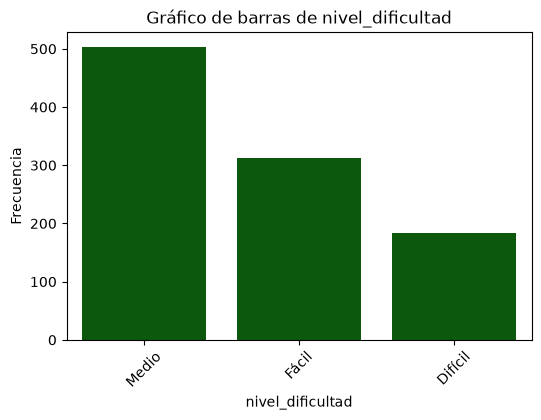

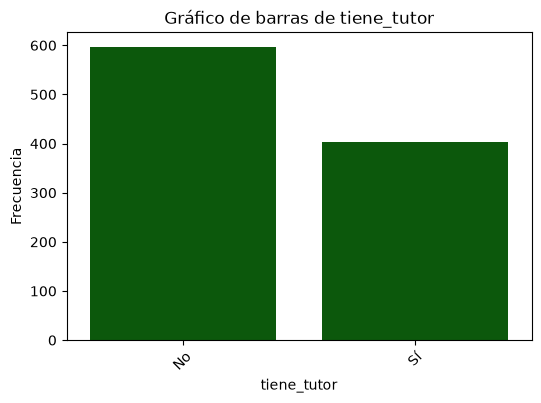

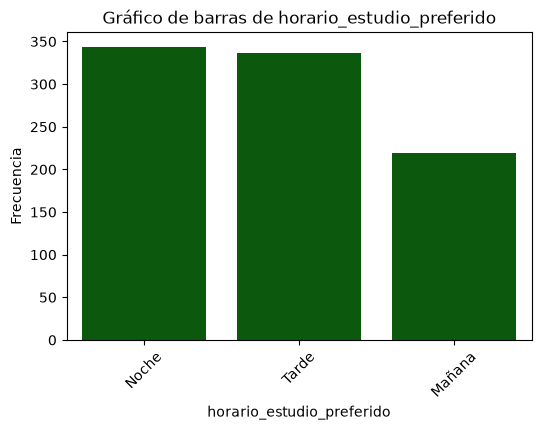

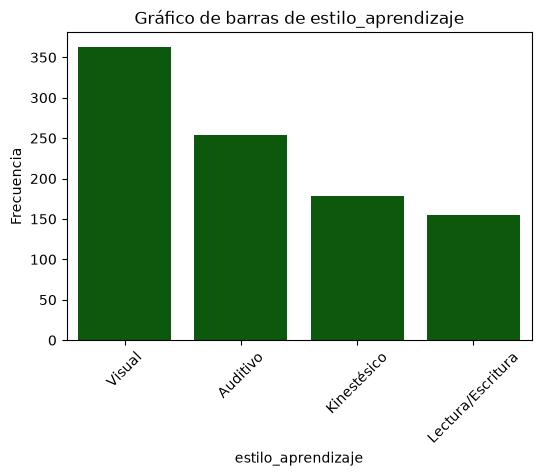

In [ ]:
for col in cat_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(x=df[col], order=df[col].value_counts().index, color='darkgreen')

    plt.title(f'Gráfico de barras de {col}')
    plt.xlabel(col)
    plt.ylabel('Frecuencia')
    plt.xticks(rotation=45)

    plt.show()

---

### 🔗 Matriz de correlación 

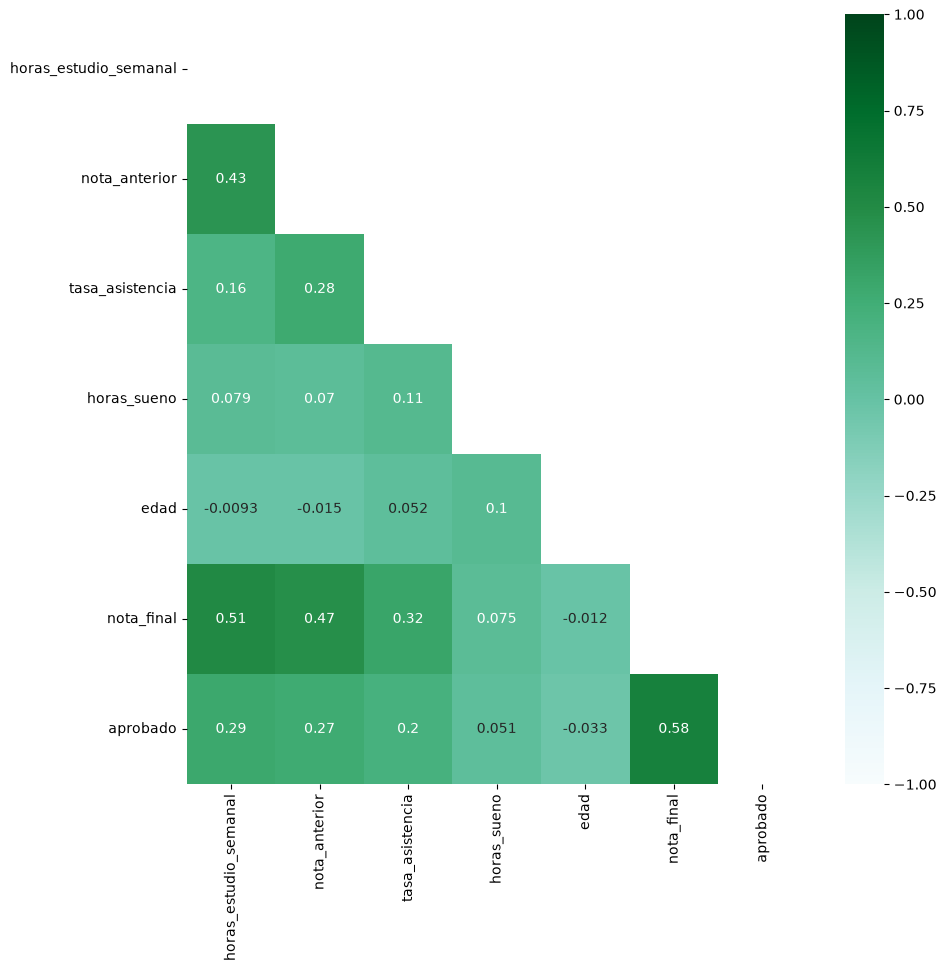

In [45]:
# Calcular la matriz de correlación
corr_matrix = df.corr(numeric_only=True)

# Crear la figura
plt.figure(figsize=(10, 10))

# Crear una máscara para mostrar solo la parte triangular
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Graficar el mapa de calor
sns.heatmap(corr_matrix, 
            annot=True, 
            vmin=-1, 
            vmax=1, 
            mask=mask,
            cmap='BuGn')

plt.show()

Las horas de estudio y la nota obtenida anteriormente son las variables que presentan una mayor asociación positiva con la nota final. La asistencia también muestra una relación positiva, aunque más moderada. Por otro lado, la edad y las horas de sueño presentan una relación prácticamente inexistente con la nota final.

---

### 🔀 Relaciones cruzadas

#### Variable objetivo numérica `nota_final`

Gráficos de dispersión

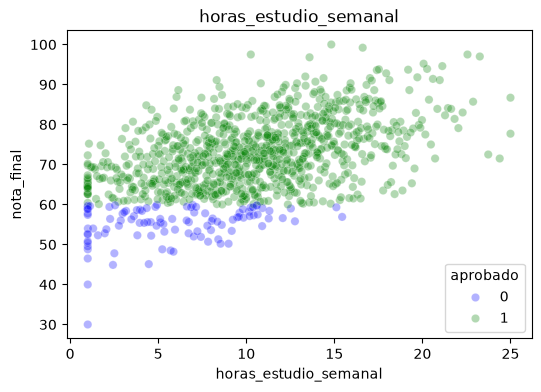

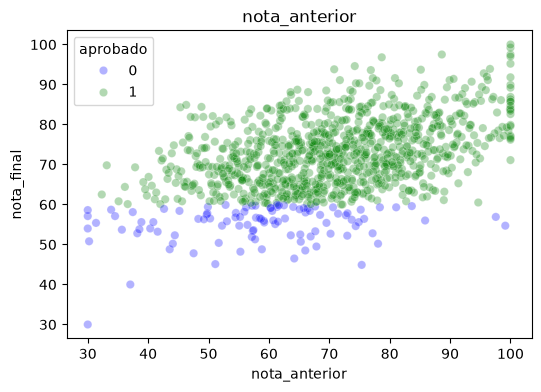

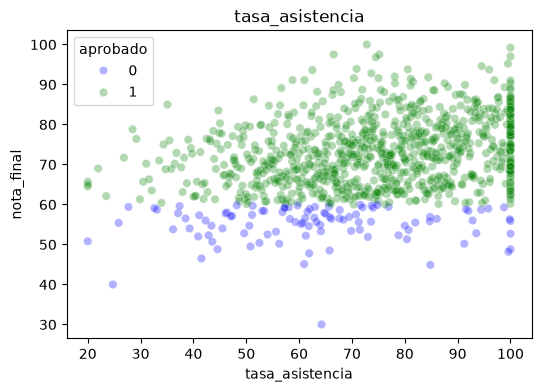

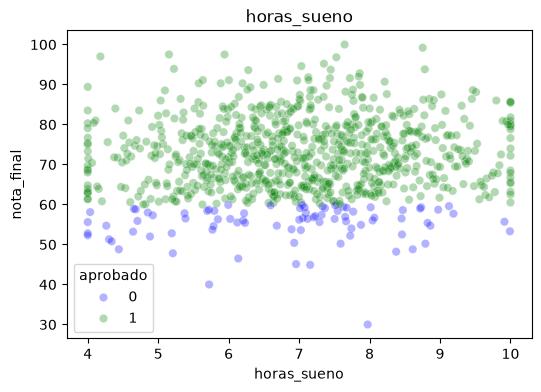

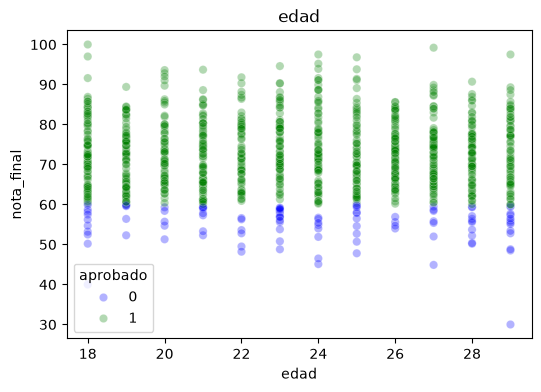

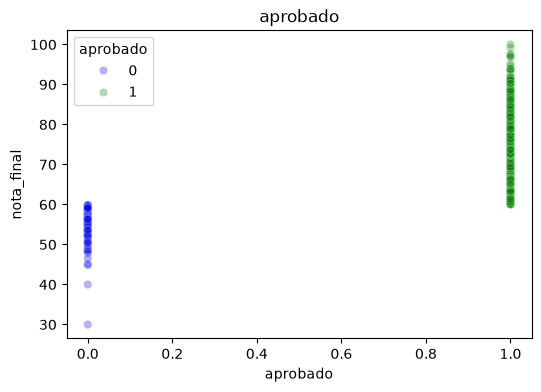

In [50]:
# Definir la variable objetivo
tv = 'nota_final'

# Definir DataFrame y variables numéricas
df_num = df.select_dtypes(include=np.number).drop(columns=[tv], errors='ignore')
cols_num = df_num.columns

# Paleta de colores
palette = {
    0: 'blue',
    1: 'green'
}

# Generar gráficos de dispersión
for col in cols_num:
    plt.figure(figsize=(6, 4))
    sns.scatterplot(x=df[col], y=df[tv], hue=df['aprobado'], palette=palette, alpha=0.3)
  
    plt.title(col)
    plt.xlabel(col)
    plt.ylabel(tv)
    plt.show()

Boxplots

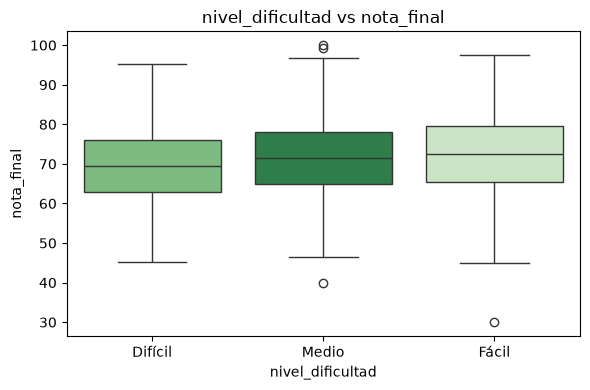

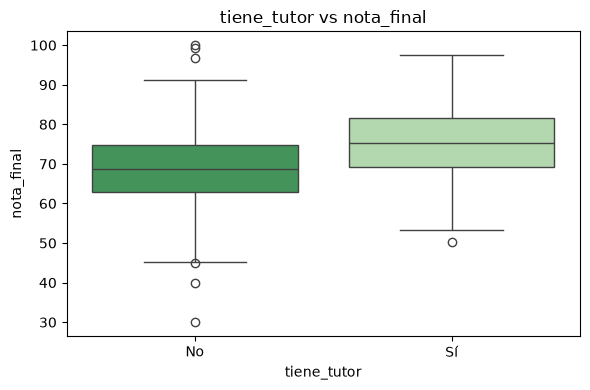

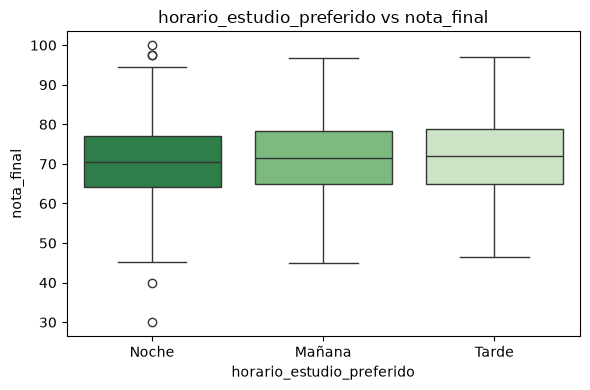

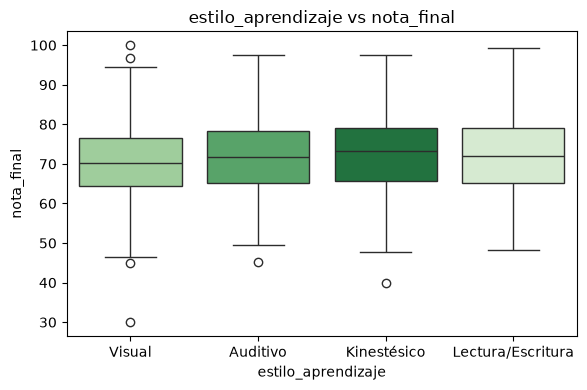

In [61]:
# Definir la variable objetivo
tv = 'nota_final'

# Generar gráficos independientes para cada variable categórica
for col in cat_cols:
    # Ordenar las categorías por el promedio de la variable objetivo
    ordered_cats = df.groupby(col)[tv].mean().sort_values().index

    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col], y=df[tv], hue=df[col], data=df, order=ordered_cats, palette='Greens' , legend=False)
    
    plt.title(f"{col} vs {tv}")
    plt.xlabel(col)
    plt.ylabel(tv)
    plt.tight_layout()
    plt.show()

#### Variable objetivo categórica `aprobado`

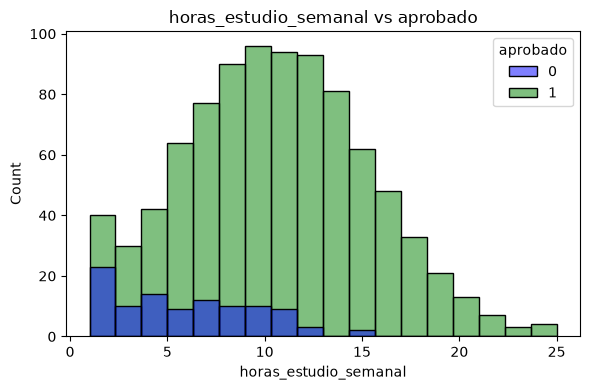

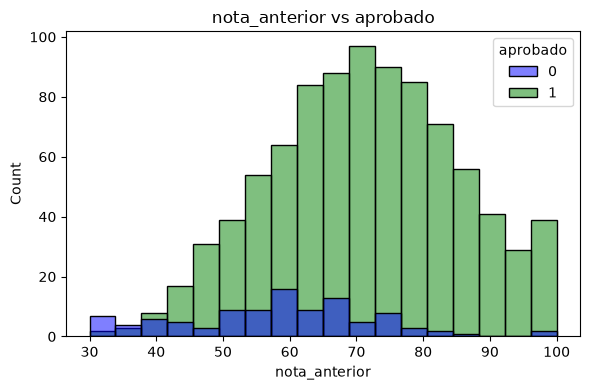

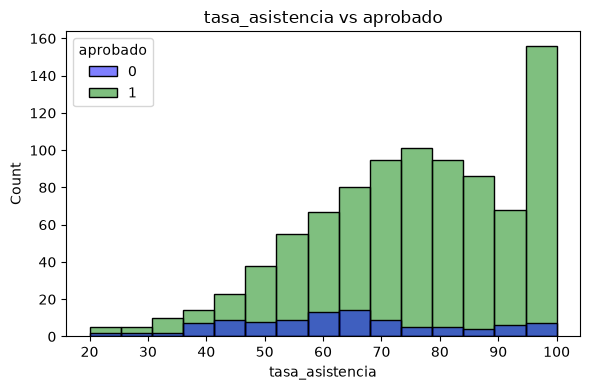

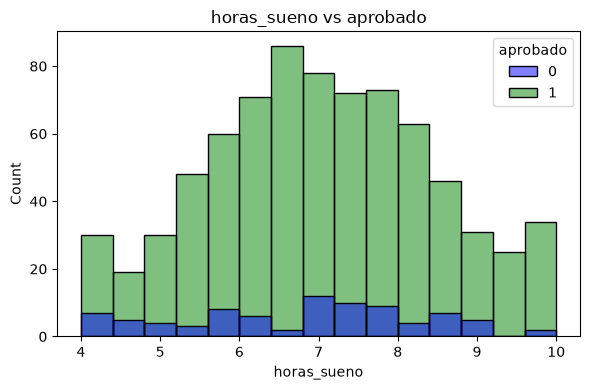

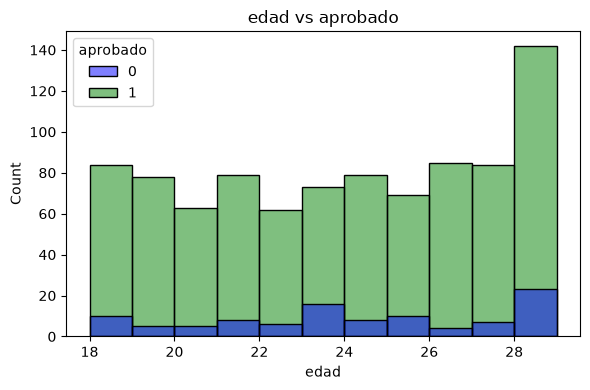

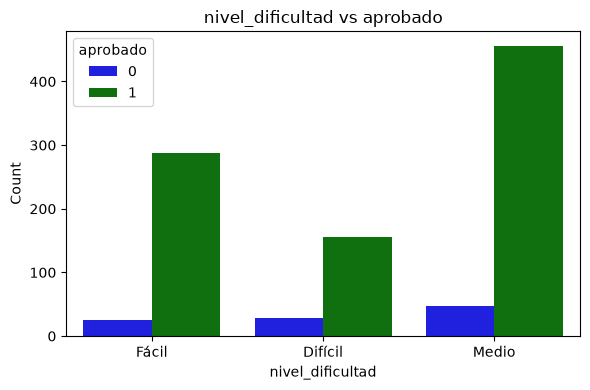

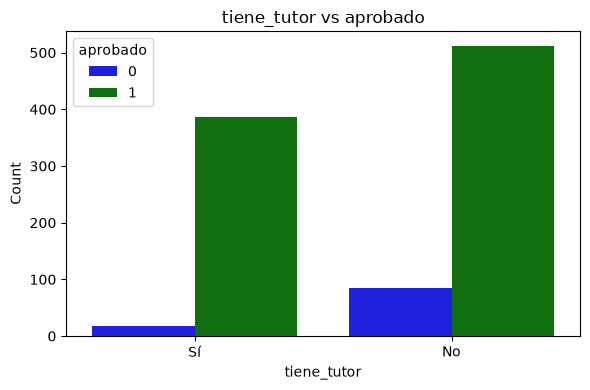

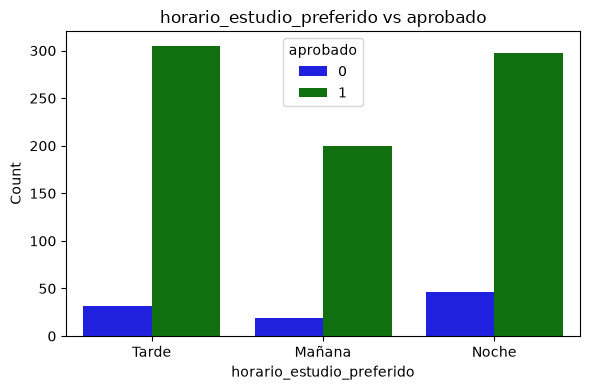

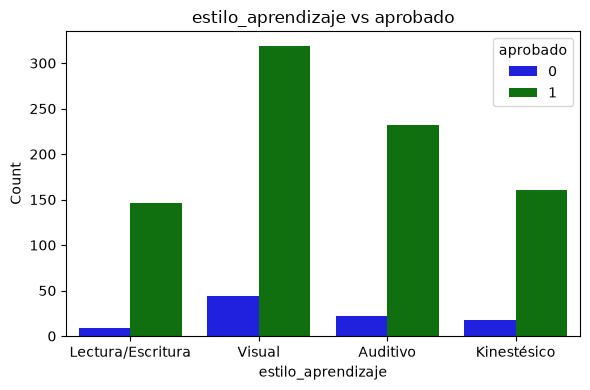

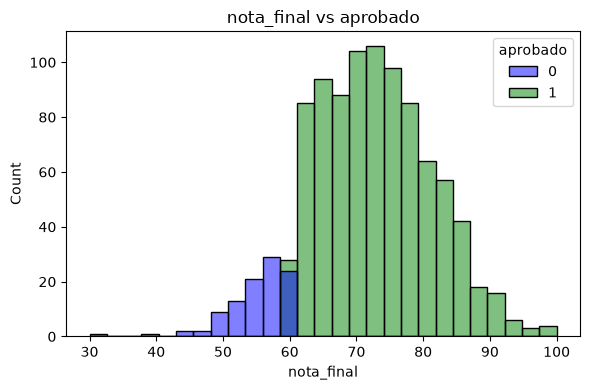

In [75]:
# Definir la variable objetivo
tv = 'aprobado'

for col in df.columns:
    # Saltar la variable objetivo
    if col == tv:
        continue

    plt.figure(figsize=(6,4))

    palette = {
    0: 'blue',
    1: 'green'
}

    if col in num_cols:
        sns.histplot(x=df[col], hue=df[tv], data=df, palette=palette, legend=True)
    elif col in cat_cols:
        sns.countplot(x=df[col], hue=df[tv], data=df, palette=palette)

    plt.title(f"{col} vs {tv}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

---

### ⚠️ Inconsistencias

#### Comprobamos valores mínimos y máximos de las columnas numéricas

In [77]:
# Valores mínimos y máximos
df[num_cols].agg(['min', 'max']).T

,min,max
horas_estudio_semanal,1.0,25.0
nota_anterior,30.0,100.0
tasa_asistencia,20.0,100.0
horas_sueno,4.0,10.0
edad,18.0,29.0
nota_final,30.0,100.0
aprobado,0.0,1.0


#### Coherencia entre `nota_final` y `aprobado`

In [79]:
inconsistencias = df[((df['nota_final'] >= 60) & (df['aprobado'] != 1)) |
                     ((df['nota_final'] < 60) & (df['aprobado'] != 0))]

if inconsistencias.empty:
    print("Las columnas son coherentes entre sí.")
else:
    print("Se han detectado inconsistencias entre las columnas.")

Las columnas son coherentes entre sí.


---
---

## <span style="color:gray">**Conclusiones del análisis exploratorio**</span> 📌


El análisis exploratorio muestra que el dataset está compuesto por 1.000 registros y 11 variables, sin registros duplicados y con rangos de valores coherentes para las variables analizadas.

Se han identificado valores faltantes en `horas_sueno`, `horario_estudio_preferido` y `estilo_aprendizaje`, por lo que será necesario establecer una estrategia para su tratamiento antes de entrenar los modelos.

El análisis de las variables numéricas y categóricas permite observar diferentes patrones de distribución y posibles asociaciones con la `nota_final`. Las relaciones cruzadas y los gráficos realizados muestran que algunas variables presentan diferencias en la distribución de las notas según sus valores o categorías, aunque estas asociaciones no implican necesariamente una relación causal.

La variable `aprobado` está directamente definida a partir de `nota_final`, por lo que deberá tenerse en cuenta esta relación durante el modelado para evitar problemas de fuga de información. En el caso de un modelo de clasificación cuyo objetivo sea predecir aprobado, `nota_final` no deberá utilizarse como variable predictora.

En conjunto, el análisis exploratorio permite identificar las principales características y posibles variables relevantes del dataset, proporcionando una base para la siguiente fase: el tratamiento de los datos y la construcción y evaluación de los modelos de Machine Learning.